<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- NEURAL NETWORKS --

## Import dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushikhushikhushi/dog-breed-image-dataset")
print('Path to dataset:', path)
!mv "$path" ./
!mv ./1/dataset ./dataset
!rmdir ./1

100%|██████████| 3.98M/3.98M [00:00<00:00, 182MB/s]

Extracting files...
Path to dataset: /root/.cache/kagglehub/datasets/khushikhushikhushi/dog-breed-image-dataset/versions/1


## Import libraries
* PIL library is used to load the images.
* Tensorflow is used as the Neural Network engine.

In [2]:
import os
import PIL
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas
import tensorflow as tf
from sklearn.model_selection import train_test_split

## View class names
Loading the class ids according to the folder names.

In [3]:
class_names = sorted(os.listdir('dataset'))
class_ids = {label: i for i, label in enumerate(class_names)}
class_ids

{'Beagle': 0,
 'Boxer': 1,
 'Bulldog': 2,
 'Dachshund': 3,
 'German_Shepherd': 4,
 'Golden_Retriever': 5,
 'Labrador_Retriever': 6,
 'Poodle': 7,
 'Rottweiler': 8,
 'Yorkshire_Terrier': 9}

Display an image from the dataset

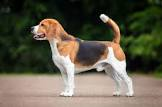

In [4]:
image_filepath = 'dataset/Beagle/Beagle_1.jpg'
image = PIL.Image.open(image_filepath)
image

## Load and Preprocess Images

Loads 967 images RGB images (3 channels), each one resized at (128,128). The target breeds are encoded as integers, according to their class id.

In [5]:
image_size = (128, 128)

inputs = []
targets = []
for label in class_names:
  for filename in os.listdir(f'dataset/{label}'):
    filepath = f'dataset/{label}/{filename}'
    img = PIL.Image.open(filepath).convert('RGB').resize(image_size)
    inputs.append(img)
    targets.append(class_ids[label])
inputs = np.float32(inputs)
targets = np.int32(targets)

inputs.shape, targets.shape


((967, 128, 128, 3), (967,))

<BarContainer object of 10 artists>

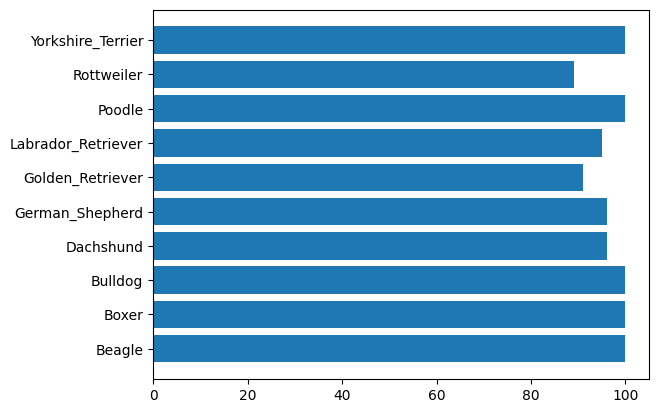

In [6]:
target_counts = np.unique(targets, return_counts=True)
plt.barh(class_names, target_counts[1])

## Load input as dataset

In [7]:
seed = 0
tf.random.set_seed(seed=seed)
np.random.seed(seed=seed)
random.seed(seed)

In [8]:
test_size = .3
stratify = [targets.shape]

x_train, x_test, y_train, y_test = train_test_split(
    inputs, targets,
    test_size=test_size,
    stratify=targets,
    random_state=seed
)

## Preprocess Dataset
1. Normalizing inputs in [0.0, 1.0] by dividing with 255.0 (Min Pixel value is 0.0, Max Pixel value is 255.0).
2. One-Hot encoding targets to enable the use of Softmax Activation Function.

In [9]:
x_train /= 255.0
x_test /= 255.0
y_train = np.eye(len(class_names))[y_train]
y_test = np.eye(len(class_names))[y_test]

y_train.shape, y_test.shape

((676, 10), (291, 10))

## Building a Multi-Layer Perceptron
* Input: (128, 128, 3) which is flattened into a vector of 49152 size.
* Output: 10 (same as number of classes).

In [10]:
input_size = x_train.shape[1:]
output_size = len(class_names)

mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True),
], name='MLP')
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,309,386 (24.07 MB)

 Trainable params: 6,309,386 (24.07 MB)

 Non-trainable params: 0 (0.00 B)

## Training a Neural Network
* Optimizer: Adam
* Learning Rate: 0.001
* Loss Function: Categorical Cross-Entropy
* Metrics: Accuracy
* Batch Size: 32
* Epochs: 50

In [11]:
optim = tf.keras.optimizers.Adam(learning_rate=0.001)
mlp.compile(optimizer=optim, loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
batch_size = 32
epochs = 50

history = mlp.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.0955 - loss: 17.8023 - val_accuracy: 0.1340 - val_loss: 5.8898
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1585 - loss: 3.8923 - val_accuracy: 0.1478 - val_loss: 2.4327
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3010 - loss: 1.9024 - val_accuracy: 0.3643 - val_loss: 2.0518
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4160 - loss: 1.7329 - val_accuracy: 0.4467 - val_loss: 1.8286
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5584 - loss: 1.4254 - val_accuracy: 0.4296 - val_loss: 1.6769
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6193 - loss: 1.2007 - val_accuracy: 0.5326 - val_loss: 1.3568
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7530 - loss: 0.9153 - val_accuracy: 0.6151 - val_loss: 1.1607
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8093 - loss: 0.7514 - val_accuracy: 0.6426 - val

## Evaluating model performance
1. Train-Test Loss
2. Train-Test Accuracy

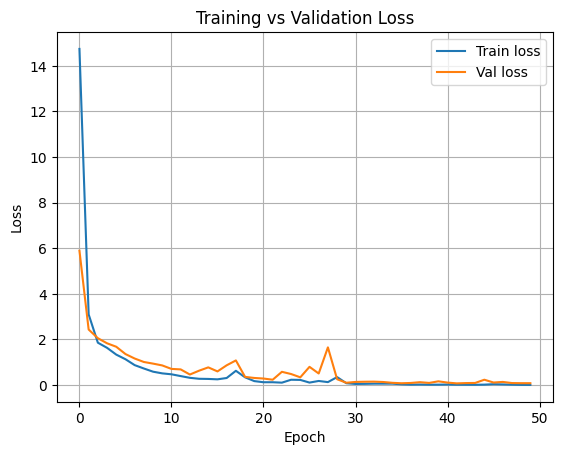

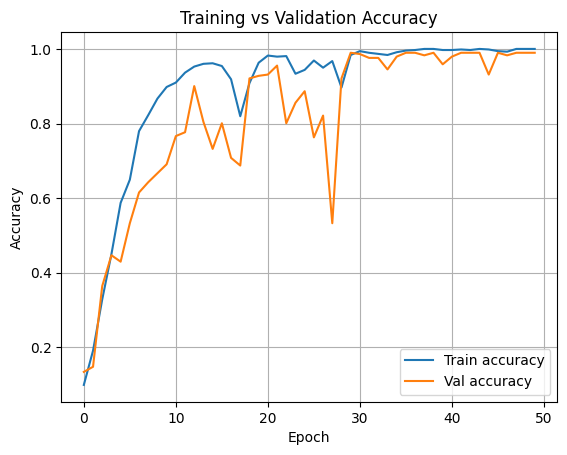

In [13]:
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Building a Convolutional Neural Network

In [15]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=2, activation='relu', use_bias=True),
    tf.keras.layers.Dropout(rate=.2),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, activation='relu', use_bias=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True)
], name='CNN')
cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 63, 63, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 119072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    15,241,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,252,778 (58.18 MB)

 Trainable params: 15,252,778 (58.18 MB)

 Non-trainable params: 0 (0.00 B)

## Training the CNN

In [17]:
optim = tf.keras.optimizers.Adam(learning_rate=0.001)
cnn.compile(optimizer=optim, loss='categorical_crossentropy', metrics=['accuracy'])

history = cnn.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.1275 - loss: 4.2364 - val_accuracy: 0.2268 - val_loss: 2.2275
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3381 - loss: 2.0955 - val_accuracy: 0.5326 - val_loss: 1.4823
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7332 - loss: 1.0297 - val_accuracy: 0.9450 - val_loss: 0.3610
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9737 - loss: 0.1853 - val_accuracy: 0.9794 - val_loss: 0.1721
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9955 - loss: 0.0566 - val_accuracy: 0.9759 - val_loss: 0.1173
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9974 - loss: 0.0369 - val_accuracy: 0.9897 - val_loss: 0.0882
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9897 - val_loss: 0.0889
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9897 - 

## CNN evaluation
1. Train-Test Loss
2. Train-Test Accuracy

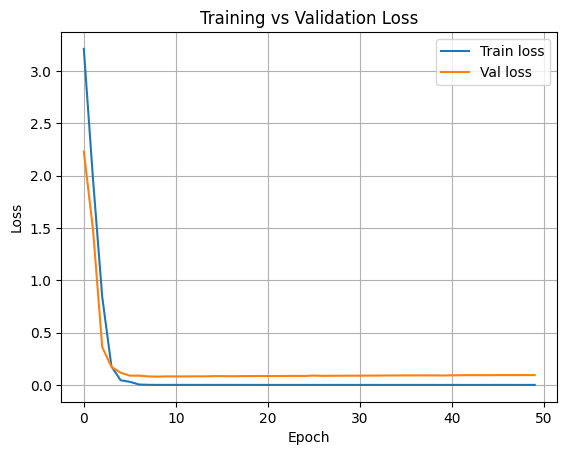

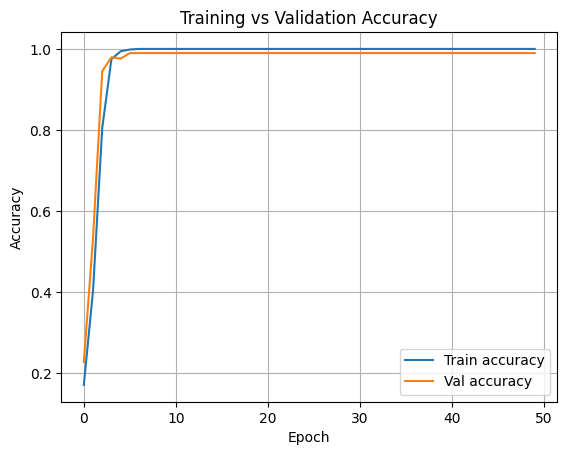

In [18]:
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Why is the CNN better at image classification than an MLP?
Firstly, the MLP treats an image a 1D vectors, as it flattens it, therefore losing any and all spatial information available in the image.

Images, however, consist of spatial information. Just like the human eye, the CNN captures spatial information about each area of the image, and by leveraging the loss function, it learns to capture the information that allows for correct classification results.

## Improving the CNN's performance!

In [64]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    # tf.keras.layers.LayerNormalization(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=2, activation='relu', use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, activation='relu', use_bias=True),
    # tf.keras.layers.LayerNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dropout(rate=.15),
    tf.keras.layers.Dense(units=64, activation='relu', use_bias=True),
    tf.keras.layers.Dropout(rate=.1),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True)
], name='CNN')
cnn.summary()

optim = tf.keras.optimizers.Adam(learning_rate=0.001)
cnn.compile(optimizer=optim, loss='categorical_crossentropy', metrics=['accuracy'])

history = cnn.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_9           │ (None, 128, 128, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 63, 63, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,006 (3.14 MB)

 Trainable params: 822,000 (3.14 MB)

 Non-trainable params: 6 (24.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.1591 - loss: 2.2962 - val_accuracy: 0.1340 - val_loss: 2.2651
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4583 - loss: 1.6850 - val_accuracy: 0.3196 - val_loss: 2.0262
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7172 - loss: 0.9592 - val_accuracy: 0.4914 - val_loss: 1.5598
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8827 - loss: 0.4300 - val_accuracy: 0.9003 - val_loss: 0.9098
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9585 - loss: 0.1667 - val_accuracy: 0.9175 - val_loss: 0.5198
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9848 - loss: 0.0614 - val_accuracy: 0.9897 - val_loss: 0.2345
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9901 - loss: 0.0374 - val_accuracy: 0.9931 - val_loss: 0.1627
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9980 - loss: 0.0169 - val_accuracy: 0.9931 - 

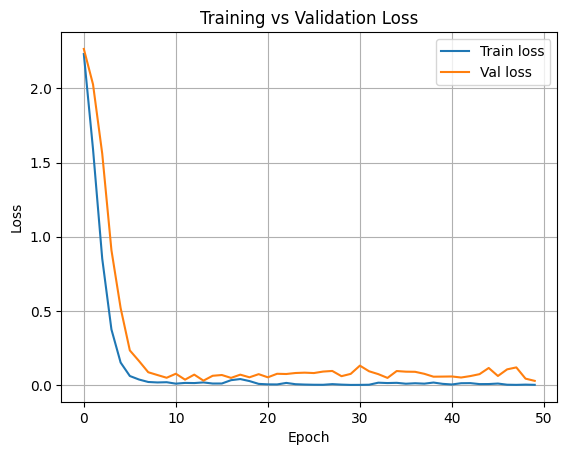

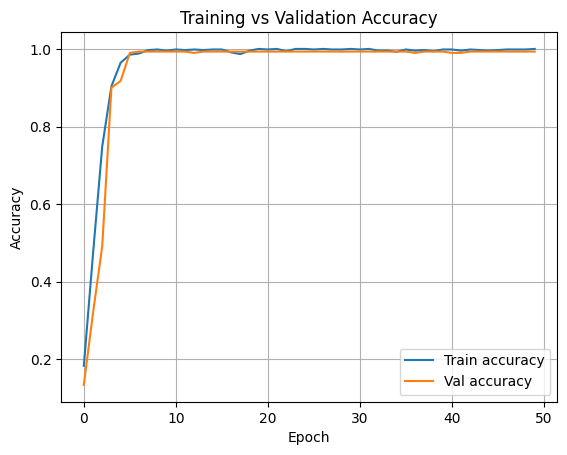

In [65]:
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()